In [16]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split

In [18]:
data = pd.read_csv('transformed/all_2p_house_races_trainset.csv')
data.head()

,Unnamed: 0,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,...,dem_inc_dummy,rep_inc_dummy,pvi,census_region,dem_scandal_score,rep_scandal_score,Year,Geography,dem_stand,rep_stand
0,0,2018,Alabama,AL,False,AL-01,89226.0,153228.0,242617,Robert Kennedy Jr.,...,0,1,-15.715056,East South Central,0.0,0.0,2018.0,AL-01,Robert Kennedy Jr.,Bradley Byrne
1,1,2018,Alabama,AL,False,AL-02,86931.0,138879.0,226230,Tabitha Isner,...,0,1,-16.880853,East South Central,0.0,0.0,2018.0,AL-02,Tabitha Isner,Martha Roby
2,2,2018,Alabama,AL,False,AL-03,83996.0,147770.0,231915,Mallory Hagan,...,0,1,-17.206974,East South Central,0.0,0.0,2018.0,AL-03,Mallory Hagan,Mike Rogers
3,3,2018,Alabama,AL,False,AL-04,46492.0,184255.0,230969,Lee Auman,...,0,1,-31.882701,East South Central,0.0,0.0,2018.0,AL-04,Lee Auman,Robert Aderholt
4,4,2018,Alabama,AL,False,AL-05,101388.0,159063.0,260673,Peter Joffrion,...,0,1,-18.025364,East South Central,0.0,0.0,2018.0,AL-05,Peter Joffrion,Mo Brooks


In [19]:
data = data.set_index(['year', 'district'])
data.head()

Unnamed: 0    state state_po  special       dem       rep  \
year district                                                              
2018 AL-01              0  Alabama       AL    False   89226.0  153228.0   
     AL-02              1  Alabama       AL    False   86931.0  138879.0   
     AL-03              2  Alabama       AL    False   83996.0  147770.0   
     AL-04              3  Alabama       AL    False   46492.0  184255.0   
     AL-05              4  Alabama       AL    False  101388.0  159063.0   

               totalvotes            dem_cand         rep_cand dem_inc  ...  \
year district                                                           ...   
2018 AL-01         242617  Robert Kennedy Jr.    Bradley Byrne   False  ...   
     AL-02         226230       Tabitha Isner      Martha Roby   False  ...   
     AL-03         231915       Mallory Hagan      Mike Rogers   False  ...   
     AL-04         230969           Lee Auman  Robert Aderholt   False  ...   
     AL-05         260673      Peter Joffrion        Mo Brooks   False  ...   

              dem_inc_dummy rep_inc_dummy        pvi       census_region  \
year district                                                              
2018 AL-01                0             1 -15.715056  East South Central   
     AL-02                0             1 -16.880853  East South Central   
     AL-03                0             1 -17.206974  East South Central   
     AL-04                0             1 -31.882701  East South Central   
     AL-05                0             1 -18.025364  East South Central   

               dem_scandal_score  rep_scandal_score    Year  Geography  \
year district                                                            
2018 AL-01                   0.0                0.0  2018.0      AL-01   
     AL-02                   0.0                0.0  2018.0      AL-02   
     AL-03                   0.0                0.0  2018.0      AL-03   
     AL-04                   0.0                0.0  2018.0      AL-04   
     AL-05                   0.0                0.0  2018.0      AL-05   

                        dem_stand        rep_stand  
year district                                       
2018 AL-01     Robert Kennedy Jr.    Bradley Byrne  
     AL-02          Tabitha Isner      Martha Roby  
     AL-03          Mallory Hagan      Mike Rogers  
     AL-04              Lee Auman  Robert Aderholt  
     AL-05         Peter Joffrion        Mo Brooks  

[5 rows x 54 columns]

In [20]:
data.columns.values

array(['Unnamed: 0', 'state', 'state_po', 'special', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc',
       'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'dem_poll_avg', 'dem_effn',
       'rep_poll_avg', 'rep_effn', 'seat_number', 'prev_lean',
       'prev2_lean', 'generic_ballot_avg', 'pres_approval_avg',
       'incumbent_pres', 'ics', 'pres_approval_avg_x_incpres',
       'ics_x_incpres', 'cvap_white_pct', 'cvap_aapi_pct',
       'cvap_hisp_pct', 'cvap_black_pct', 'cvap_natam_pct', 'college',
       'no_dem_cand_flag', 'no_rep_cand_flag', 'dem_inc_any',
       'rep_inc_any', 'dem_inc_dummy', 'rep_inc_dummy', 'pvi',
       'census_region', 'dem_scandal_score', 'rep_scandal_score', 'Year',
       'Geography', 'dem_stand', 'rep_stand'], dtype=object)

In [21]:
data['rep_tot_funds'].isna().any()

np.False_

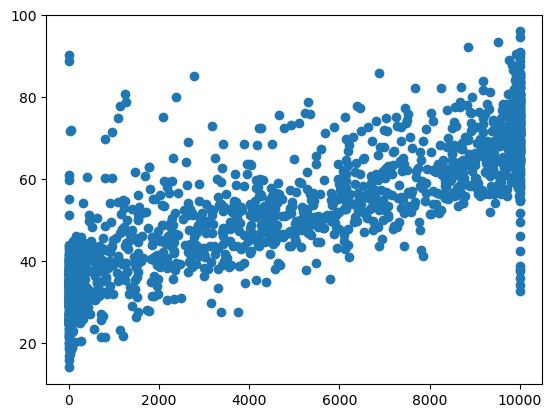

In [42]:
# plt.scatter(np.sqrt(data['dem_effn']) * (data['dem_poll_avg'] - data['rep_poll_avg']), data['dem_pct_2p'])
plt.scatter(data['dem_funds_2p_pct']**2, data['dem_pct_2p'])

<Axes: xlabel='rep_scandal_score', ylabel='dem_pct_2p'>

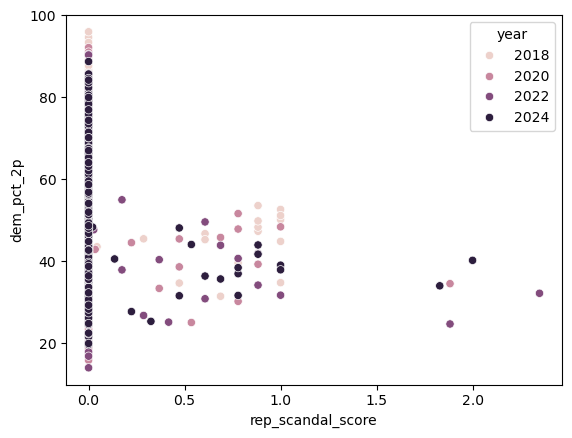

In [23]:
sns.scatterplot(
    data.reset_index(),
    x='rep_scandal_score', y='dem_pct_2p', hue='year' 
)

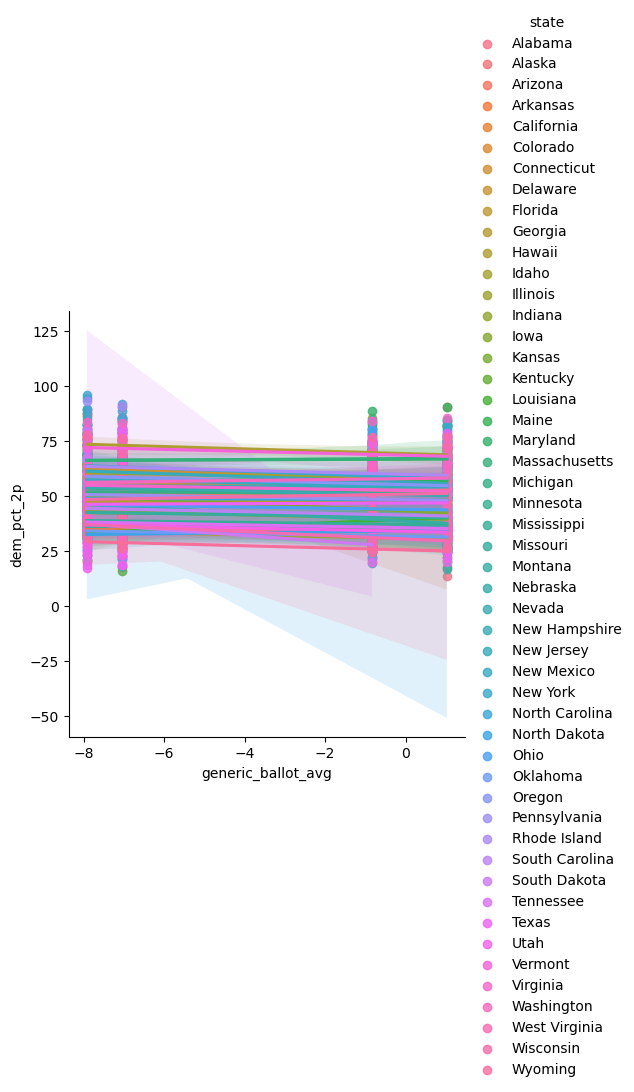

In [24]:
data_resind = data.reset_index()

sns.lmplot(
    data_resind,
    x='generic_ballot_avg', y='dem_pct_2p', hue='state'
)

In [32]:
data['dem_funds_2p_pct_sqrd'] = data['dem_funds_2p_pct']**2
data['sqrt_effn'] = np.sqrt(data['dem_effn'])
data['poll_margin'] = data['dem_poll_avg'] - data['rep_poll_avg']
data['effnXmargin'] = data['sqrt_effn'] * data['poll_margin']

## Preliminary Model Check (Frequentist OLS)

In [33]:
y = data['dem_pct_2p']
X = data[['pvi', 'generic_ballot_avg',
         'dem_inc_dummy', 'rep_inc_dummy', 'dem_funds_2p_pct_sqrd',
         'cvap_black_pct', 'cvap_hisp_pct', 'cvap_natam_pct', 'cvap_aapi_pct',
         'effnXmargin', 'college']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [34]:
X.corr()

,pvi,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,cvap_black_pct,cvap_hisp_pct,cvap_natam_pct,cvap_aapi_pct,effnXmargin,college
pvi,1.000000,0.042125,0.721324,-0.684161,0.788791,0.408579,0.364318,-0.129618,0.434812,0.170579,0.372960
generic_ballot_avg,0.042125,1.000000,0.002956,-0.036906,-0.054604,0.034323,0.059749,0.081229,0.072997,0.072951,0.124459
dem_inc_dummy,0.721324,0.002956,1.000000,-0.731589,0.700833,0.225826,0.254019,-0.056972,0.337487,0.229305,0.280765
rep_inc_dummy,-0.684161,-0.036906,-0.731589,1.000000,-0.694204,-0.223322,-0.237517,0.027644,-0.309231,-0.242253,-0.277529
dem_funds_2p_pct_sqrd,0.788791,-0.054604,0.700833,-0.694204,1.000000,0.225970,0.248420,-0.084721,0.363170,0.151406,0.342583
cvap_black_pct,0.408579,0.034323,0.225826,-0.223322,0.225970,1.000000,-0.103127,-0.130077,-0.102828,0.014783,-0.102919
cvap_hisp_pct,0.364318,0.059749,0.254019,-0.237517,0.248420,-0.103127,1.000000,0.004981,0.213686,0.041625,-0.174862
cvap_natam_pct,-0.129618,0.081229,-0.056972,0.027644,-0.084721,-0.130077,0.004981,1.000000,-0.089834,0.024713,-0.121203
cvap_aapi_pct,0.434812,0.072997,0.337487,-0.309231,0.363170,-0.102828,0.213686,-0.089834,1.000000,0.053409,0.409200
effnXmargin,0.170579,0.072951,0.229305,-0.242253,0.151406,0.014783,0.041625,0.024713,0.053409,1.000000,0.098643


In [35]:
np.linalg.matrix_rank(X)

np.int64(11)

In [36]:
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const)
reg = model.fit(cov_type='HC1')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             dem_pct_2p   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     3746.
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:23:11   Log-Likelihood:                -2611.7
No. Observations:                1072   AIC:                             5247.
Df Residuals:                    1060   BIC:                             5307.
Df Model:                          11                                         
Covariance Type:                  HC1                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    48.6802      0.629     77.410      0.000      47.448      49.913
pvi                       0.8847      0.014     61.638      0.000       0.857       0.913
generic_ballot_avg       -0.3559      0.022    -15.966      0.000      -0.400      -0.312
dem_inc_dummy             0.5065      0.322      1.575      0.115      -0.124       1.137
rep_inc_dummy            -1.6925      0.317     -5.334      0.000      -2.314      -1.071
dem_funds_2p_pct_sqrd     0.0005   4.64e-05     10.560      0.000       0.000       0.001
cvap_black_pct           -0.0210      0.009     -2.318      0.020      -0.039      -0.003
cvap_hisp_pct            -0.0709      0.009     -7.955      0.000      -0.088      -0.053
cvap_natam_pct            0.1662      0.041      4.096      0.000       0.087       0.246
cvap_aapi_pct            -0.0185      0.026     -0.699      0.485      -0.070       0.033
effnXmargin               0.0126      0.008      1.534      0.125      -0.003       0.029
college                   0.0159      0.012      1.346      0.178      -0.007       0.039
==============================================================================
Omnibus:                       55.619   Durbin-Watson:                   1.985
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              164.664
Skew:                           0.183   Prob(JB):                     1.75e-36
Kurtosis:                       4.885   Cond. No.                     4.02e+04
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 4.02e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [37]:
y_test_hat = reg.predict(sm.add_constant(X_test))
X_test['residuals'] = y_test_hat - y_test
np.mean((y_test - y_test_hat)**2), np.mean(abs(y_test - y_test_hat))

(np.float64(6.811542731155133), np.float64(2.00058550159844))

In [38]:
y_test - y_test_hat

year  district
2020  IL-15      -4.157667
2018  TX-31       4.714696
      MD-07      -1.649117
      IN-04      -0.591039
2022  IN-01       1.706407
                    ...   
2020  WA-05      -4.195170
2018  WA-04      -1.263322
2024  NC-12       1.474806
2018  IL-13       0.171813
2022  CA-02       0.127640
Length: 529, dtype: float64

In [39]:
X_test.corr()

,pvi,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,cvap_black_pct,cvap_hisp_pct,cvap_natam_pct,cvap_aapi_pct,effnXmargin,college,residuals
pvi,1.000000,0.028109,0.721911,-0.682265,0.800179,0.386957,0.341482,-0.074288,0.439827,0.172350,0.383286,-0.034545
generic_ballot_avg,0.028109,1.000000,-0.038077,-0.004231,-0.074937,0.048529,0.021405,0.071717,0.073986,0.063730,0.147251,-0.032144
dem_inc_dummy,0.721911,-0.038077,1.000000,-0.740432,0.702962,0.216874,0.256099,-0.025788,0.377443,0.244242,0.282442,-0.044658
rep_inc_dummy,-0.682265,-0.004231,-0.740432,1.000000,-0.690888,-0.189255,-0.261258,-0.026900,-0.328166,-0.260407,-0.275514,0.005128
dem_funds_2p_pct_sqrd,0.800179,-0.074937,0.702962,-0.690888,1.000000,0.172978,0.252560,0.002656,0.412577,0.149075,0.342584,-0.002549
cvap_black_pct,0.386957,0.048529,0.216874,-0.189255,0.172978,1.000000,-0.137109,-0.117560,-0.165630,0.000057,-0.137019,-0.094557
cvap_hisp_pct,0.341482,0.021405,0.256099,-0.261258,0.252560,-0.137109,1.000000,0.023491,0.227473,0.061389,-0.164282,-0.042270
cvap_natam_pct,-0.074288,0.071717,-0.025788,-0.026900,0.002656,-0.117560,0.023491,1.000000,-0.068980,0.118667,-0.078849,-0.031052
cvap_aapi_pct,0.439827,0.073986,0.377443,-0.328166,0.412577,-0.165630,0.227473,-0.068980,1.000000,0.059323,0.407778,0.116291
effnXmargin,0.172350,0.063730,0.244242,-0.260407,0.149075,0.000057,0.061389,0.118667,0.059323,1.000000,0.087189,-0.010151


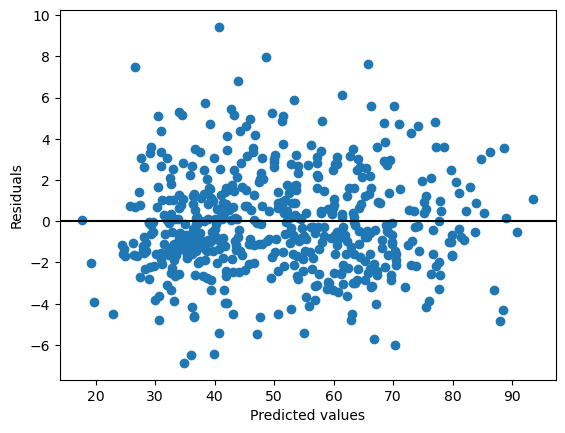

In [55]:
# Residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black')
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

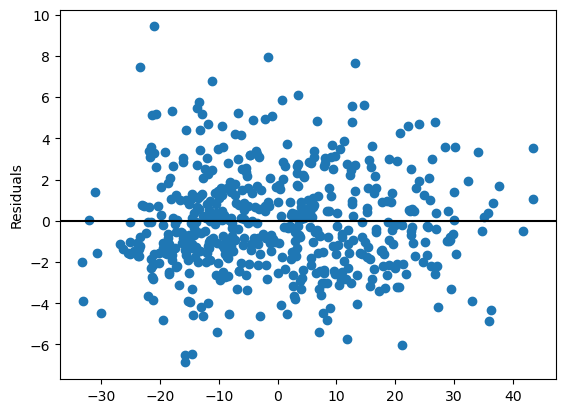

In [56]:
# Residuals
plt.scatter(X_test['prev2_lean'], y_test - y_test_hat)
plt.axhline(0, color='black')
plt.ylabel('Residuals');

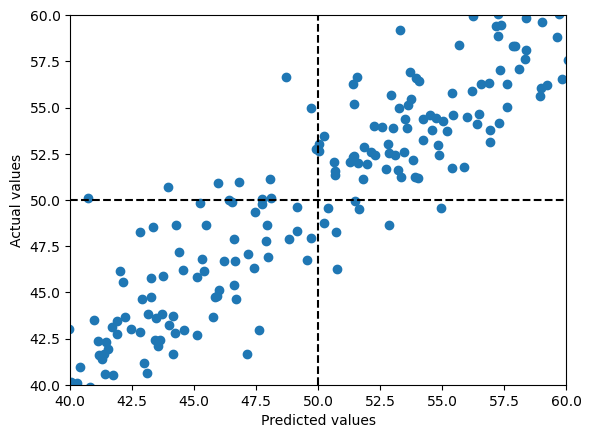

In [57]:
# Actual vs predicted
plt.scatter(y_test_hat, y_test)
plt.axhline(50, color='black', linestyle='--')
plt.axvline(50, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(40, 60)
plt.xlabel('Predicted values')
plt.ylabel('Actual values');

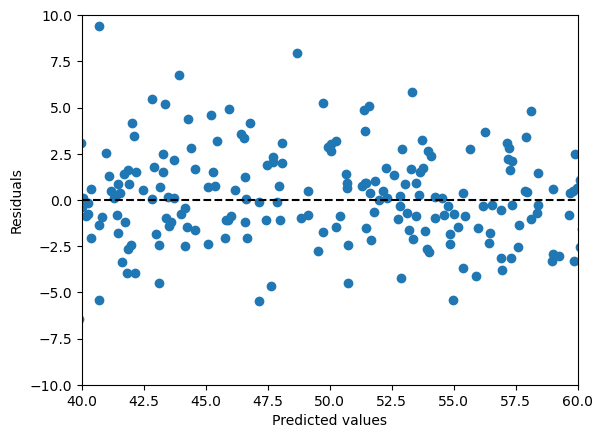

In [58]:
# Actual vs residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(-10, 10)
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [59]:
resid = pd.DataFrame(y_test_hat - y_test)
resid = resid.reset_index().rename({0: 'resid'}, axis=1)
resid.head()

,year,district,resid
0,2020,IL-15,1.544257
1,2018,TX-31,-5.173558
2,2018,MD-07,1.652631
3,2018,IN-04,0.361365
4,2022,IN-01,-1.011373


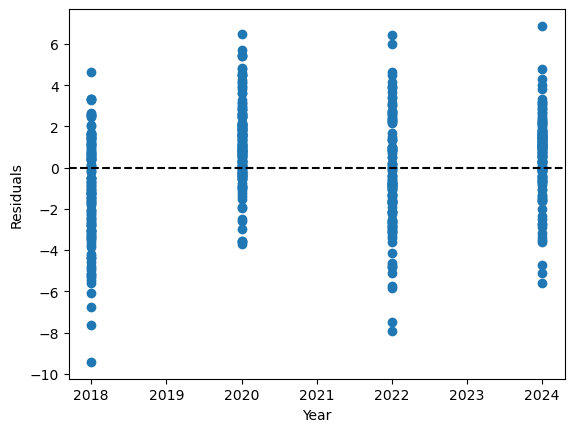

In [60]:
plt.scatter(resid['year'], resid['resid'])
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--');

In [61]:
durbin_watson(reg.resid)

np.float64(1.9784027336335988)